# Consumo de energía por manzana en el Valle de Aburrá

Medidores de EPM de `UrbanAnalysis.gdb` asignados a las manzanas del Marco Geoestadístico Nacional: dentro del polígono o a 7,5 m o menos de su borde. Los medidores sin lectura no entran en los promedios.

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter

RUTA = pathlib.Path.cwd()
GRAFICAS = RUTA / "graficas"
GRAFICAS.mkdir(exist_ok=True)

PAPEL, TINTA, TINTA_2, LINEA = "#f1f2ee", "#1d231f", "#565f56", "#d3d7cf"
COBRE = ["#cfa243", "#b8871f", "#9e6c0d", "#82550a", "#653d07", "#492905"]
PETROLEO = "#00849b"
for arch in ["framd.ttf", "corbel.ttf", "consola.ttf"]:
    ruta = pathlib.Path("C:/Windows/Fonts") / arch
    if ruta.exists():
        font_manager.fontManager.addfont(str(ruta))
mpl.rcParams.update({
    "figure.facecolor": PAPEL, "axes.facecolor": PAPEL, "savefig.facecolor": PAPEL,
    "font.family": "Corbel", "font.size": 10, "text.color": TINTA,
    "axes.edgecolor": TINTA_2, "axes.labelcolor": TINTA_2,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2, "figure.dpi": 110,
})
TIT = {"fontname": "Franklin Gothic Medium"}
DAT = {"fontname": "Consolas"}
MILES = FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))

def marco(ax, titulo, x=None, y=None, eje_y_miles=True):
    ax.set_title(titulo, loc="left", fontsize=14, pad=12, **TIT)
    if x:
        ax.set_xlabel(x)
    if y:
        ax.set_ylabel(y)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=LINEA, lw=0.9)
    ax.set_axisbelow(True)
    if eje_y_miles:
        ax.yaxis.set_major_formatter(MILES)

def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(GRAFICAS / nombre, dpi=200)

def n(x, dec=0):
    return f"{x:,.{dec}f}".replace(",", "@").replace(".", ",").replace("@", ".")

from IPython.display import Markdown

def fragmento(archivo, desde, hasta):
    """Muestra el trozo del script que va entre dos anclas de texto."""
    lineas = (RUTA / archivo).read_text(encoding="utf-8").split("\n")
    i = next(k for k, l in enumerate(lineas) if desde in l)
    j = next(k for k, l in enumerate(lineas[i + 1:], i + 1) if hasta in l)
    codigo = "\n".join(lineas[i:j]).rstrip()
    return Markdown("```python\n" + codigo + "\n```")

med = pd.read_csv(RUTA / "medidores_asignados.csv", low_memory=False)
manz = pd.read_csv(RUTA / "manzanas_amva_medidores.csv", low_memory=False)
MPIO = {"Medellin": "Medellín", "Itagui": "Itagüí"}
med["N_Mpio"] = med.N_Mpio.replace(MPIO)

# El cero de Csmo_Prom es dato censurado, no consumo cero: se trata como ausente.
med["lectura"] = med.Csmo_Prom.replace(0, np.nan)
asignados = med[med.metodo != "no_asignado"]
res = asignados[(asignados.Categoria == "RESIDENCIAL") & (asignados.ESTRATO.between(1, 6))]

print("medidores:", n(len(med)), "| asignados a una manzana:", n(len(asignados)),
      "| residenciales con lectura:", n(int(res.lectura.notna().sum())))

medidores: 1.362.005 | asignados a una manzana: 1.303.743 | residenciales con lectura: 1.136.911


## De dónde salen los datos

In [2]:
import subprocess
import time

ORIGEN = RUTA.parent / "UrbanAnalysis.gdb"
ARCHIVOS = ["manzanas_medidores.gpkg", "medidores_asignados.csv",
            "manzanas_amva_medidores.csv"]

# Si falta alguno se reconstruye desde la geodatabase: son 50 segundos.
faltan = [a for a in ARCHIVOS if not (RUTA / a).exists()]
if faltan:
    print("reconstruyendo:", ", ".join(faltan))
    subprocess.run([sys.executable, str(RUTA / "01_asignar_medidores.py")], check=True)

print("origen:", ORIGEN.name, "|", n(sum(f.stat().st_size for f in ORIGEN.iterdir()) / 1e6, 1), "MB")
for a in ARCHIVOS:
    ruta = RUTA / a
    print("  %-28s %8s MB   %s" % (a, n(ruta.stat().st_size / 1e6, 1),
                                   time.strftime("%Y-%m-%d %H:%M", time.localtime(ruta.stat().st_mtime))))

origen: UrbanAnalysis.gdb | 1.200,2 MB
  manzanas_medidores.gpkg         366,6 MB   2026-08-19 14:08
  medidores_asignados.csv         208,7 MB   2026-08-19 14:09
  manzanas_amva_medidores.csv       4,0 MB   2026-08-19 14:08


El punto de una dirección cae sobre la fachada, no dentro del predio. Por eso una
unión espacial por intersección, que es lo que uno haría por defecto, pierde
**465.499 medidores, el 34 % del total**.

La regla que resuelve eso: **un medidor cuenta para una manzana si cae dentro de
ella o si está a 7,5 m o menos de su borde**, medido al borde y no al centroide.
El resto de esta sección es cómo se programa esa regla, paso por paso.

### 1. Leer las dos capas, ya filtradas

El `where` filtra al leer, no después: en vez de cargar las 504.996 manzanas del
país y botar el 96 %, trae solo las 22.000 del valle. El `force_2d` quita las
coordenadas Z y M de la capa de EPM, que vienen con basura y hacen fallar varias
operaciones espaciales.

In [3]:
fragmento("01_asignar_medidores.py", "campos_censo = ", "log(" + chr(34) + "medidores:")

```python
campos_censo = ['COD_DANE_A', 'MPIO_CDPMP', 'CLAS_CCDGO', 'TVIVIENDA', 'TP16_HOG',
                'TP27_PERSO', 'TP19_EE_1'] + ['TP19_EE_E%d' % e for e in range(1, 7)]
manz = gpd.read_file(
    GDB, layer='MGN_ANM_MANZANA', columns=campos_censo,
    where="MPIO_CDPMP IN (%s)" % ','.join("'%s'" % m for m in MUNICIPIOS))
manz['area_ha'] = manz.area / 10_000
log("manzanas del Valle de Aburra: %d" % len(manz))

# ---------------------------------------------------------------- medidores
med = gpd.read_file(GDB, layer='IEpm_DensUrbam', columns=[
    'Direccion', 'Categoria', 'Csmo_Prom', 'ESTRATO', 'Suelo', 'N_Mpio', 'C_DensUrba'])
med = med.set_geometry(shapely.force_2d(med.geometry.values))  # la capa trae Z y M basura
xy = shapely.get_coordinates(med.geometry.values)
med['X'], med['Y'] = xy[:, 0], xy[:, 1]
```

### 2. Agrupar por coordenada

Este es el paso que más trabajo ahorra. En un edificio de 40 apartamentos los 40
contadores tienen la misma dirección, y por lo tanto el mismo punto: calcular 40
veces la misma distancia es desperdicio. Los **1.362.005 medidores se reducen a
589.799 puntos distintos**, menos de la mitad.

Además evita un error: si se calcularan por separado, dos contadores del mismo
edificio podrían terminar en manzanas distintas.

In [4]:
fragmento("01_asignar_medidores.py", "coord = med.groupby(", "log(" + chr(34) + "coordenadas unicas")

```python
coord = med.groupby(['X', 'Y'], sort=False).agg(
    n_medidores=('Direccion', 'size'), direccion=('Direccion', 'first')).reset_index()
puntos = shapely.points(coord.X.values, coord.Y.values)
```

### 3. Preguntar qué manzanas están cerca, y medir

Un `STRtree` es un índice espacial y funciona como el índice de un libro. Sin él
habría que comparar cada punto con cada manzana: 589.799 x 22.000 = **13.000
millones de comparaciones**. Con el índice uno pregunta *cuáles manzanas están a
menos de 9,5 m de este punto* y devuelve una o dos. Salen 778.128 parejas y tarda
4 segundos.

Después `shapely.distance` mide, para cada pareja, la **distancia exacta del punto
al borde** de esa manzana. Al borde, no al centro.

¿Por qué 9,5 y no 7,5? Porque es el umbral más 2 m de margen, y esos 2 m se
necesitan en el paso siguiente.

In [5]:
fragmento("01_asignar_medidores.py", "arbol = shapely.STRtree", "log(" + chr(34) + "parejas punto-manzana")

```python
arbol = shapely.STRtree(manz.geometry.values)
i_pt, i_mz = arbol.query(puntos, predicate='dwithin', distance=UMBRAL + AMBIGUO)
dist = shapely.distance(puntos[i_pt], manz.geometry.values[i_mz])
```

### 4. Escoger la manzana y clasificar

Se ordenan las parejas por distancia y se toman **las dos primeras** de cada
punto. La primera es la manzana asignada. La segunda sirve para saber si esa
decisión es confiable: si está a menos de 2 m de diferencia, el medidor está sobre
el eje de la vía, gana una manzana por centímetros y queda marcado como `ambiguo`.

Las tres clases: distancia cero es `dentro`, hasta 7,5 m es `cercano`, más lejos
es `no_asignado` y no se fuerza. Un punto dentro del polígono da distancia cero y
gana sin competencia, así que la misma línea resuelve los dos casos.

In [6]:
fragmento("01_asignar_medidores.py", "pares = (pd.DataFrame", "log(" + chr(34) + "coordenadas -> dentro")

```python
pares = (pd.DataFrame({'pt': i_pt, 'mz': i_mz, 'd': dist})
           .sort_values(['pt', 'd'], kind='stable'))
primera = pares.drop_duplicates('pt', keep='first')
resto = pares.drop(primera.index)
segunda = resto.drop_duplicates('pt', keep='first')

coord['manz_i'] = -1
coord['dist_m'] = np.nan
coord.loc[primera.pt.values, 'manz_i'] = primera.mz.values
coord.loc[primera.pt.values, 'dist_m'] = primera.d.values

dif_2da = pd.Series(np.nan, index=coord.index)
d_primera = pd.Series(primera.d.values, index=primera.pt.values)
dif_2da.loc[segunda.pt.values] = segunda.d.values - d_primera.reindex(segunda.pt.values).values

coord['metodo'] = np.where(coord.dist_m == 0, 'dentro',
                  np.where(coord.dist_m <= UMBRAL, 'cercano', 'no_asignado'))
coord.loc[coord.metodo == 'no_asignado', 'manz_i'] = -1
coord['ambiguo'] = ((coord.metodo == 'cercano') & (dif_2da <= AMBIGUO)).astype('int8')
coord['cod_manzana'] = np.where(coord.manz_i >= 0,
                                manz.COD_DANE_A.values[coord.manz_i.clip(lower=0)], '')
```

### 5. Devolver el resultado a cada medidor

Un `merge` por coordenada reparte la respuesta a los 1.362.005 medidores: los 40
contadores del edificio reciben la misma manzana. Aquí queda listo el contenido de
`medidores_asignados.csv`.

In [7]:
fragmento("01_asignar_medidores.py", "med = med.merge(coord[", "total = len(med)")

```python
med = med.merge(coord[['X', 'Y', 'cod_manzana', 'dist_m', 'metodo', 'ambiguo',
                       'dir_resuelve']],
                on=['X', 'Y'], how='left')
```

### 6. Contar por manzana y escribir los archivos

Para el segundo CSV se agrupa al revés, por `cod_manzana`, y se pega el resultado
a la tabla de manzanas con sus variables del censo.

In [8]:
fragmento("01_asignar_medidores.py", "g = pd.DataFrame({", "out = manz.merge(g")

```python
g = pd.DataFrame({
    'medidores':       asig.groupby('cod_manzana').size(),
    'med_residencial': res.groupby('cod_manzana').size(),
    'med_comercial':   asig[asig.Categoria == 'COMERCIAL'].groupby('cod_manzana').size(),
    'med_industrial':  asig[asig.Categoria == 'INDUSTRIAL'].groupby('cod_manzana').size(),
    'med_dentro':      asig[asig.metodo == 'dentro'].groupby('cod_manzana').size(),
    'med_cercano':     asig[asig.metodo == 'cercano'].groupby('cod_manzana').size(),
    'med_ambiguo':     asig.groupby('cod_manzana').ambiguo.sum(),
    'med_dir':         asig.groupby('cod_manzana').dir_resuelve.sum(),
    'consumo_prom':    res.groupby('cod_manzana').consumo.mean().round(1),
    'consumo_mediana': res.groupby('cod_manzana').consumo.median().round(1),
    'estrato_moda':    res.groupby('cod_manzana').ESTRATO.agg(
                          lambda s: s.mode().iat[0] if len(s.mode()) else np.nan),
})
for e in range(1, 7):
    g['med_estrato%d' % e] = res[res.ESTRATO == e].groupby('cod_manzana').size()
```

`drop(columns="geometry")` es lo que convierte una capa geográfica en una tabla
común: se le quita la geometría y queda un CSV que abre pandas, Excel o Power BI.
El GPKG guarda lo mismo pero **con** geometría, que es lo que leen los mapas.

In [9]:
fragmento("01_asignar_medidores.py", "gpkg = SALIDA", "archivos escritos")

```python
gpkg = SALIDA + '/manzanas_medidores.gpkg'
out.to_file(gpkg, layer='manzanas_medidores', driver='GPKG')
med.to_file(gpkg, layer='medidores_asignados', driver='GPKG')
out.drop(columns='geometry').to_csv(SALIDA + '/manzanas_amva_medidores.csv', index=False)
med.drop(columns='geometry').to_csv(SALIDA + '/medidores_asignados.csv', index=False)
```

### 7. Desempatar con la dirección

Cuando dos manzanas quedan a casi la misma distancia, la geometría no puede
decidir. Ahí entra la nomenclatura: en `CL 88 A CR 74 -4` la placa indica el
costado de la vía, y en el **83 % de los grupos vía-manzana** las placas son de
una sola paridad.

La evidencia se toma de los medidores que caen dentro de una manzana, que son
los que no admiten duda, y con eso se rompe el empate. Contra los casos donde la
geometría sí decide, la regla **acierta el 85 %**; como en un empate la geometría
acierta el 50 %, la mejora es real. Resuelve **16.144** de los 51.155 ambiguos y
los demás quedan marcados.

In [10]:
fragmento("01_asignar_medidores.py", "PATRON = re.compile", "cambian = int(")

```python
PATRON = re.compile(
    r'^\s*(CL|CR|KR|DG|TV|DIAG|TRAN|AVDA|CIRC|AV)\s+([0-9]+)\s*([A-Z]{0,2})\s*'
    r'(SUR|ESTE|NORTE)?\s+(?:CL|CR|KR|DG|TV|DIAG|TRAN|AVDA|CIRC|AV)\s+'
    r'([0-9]+)\s*[A-Z]{0,2}\s*(?:SUR|ESTE|NORTE)?\s*-\s*([0-9]+)')
campos = coord.direccion.fillna('').str.extract(PATRON)
coord['via'] = campos[0].fillna('') + campos[1].fillna('') + campos[2].fillna('') + campos[3].fillna('')
coord.loc[campos[0].isna(), 'via'] = np.nan
coord['cruce'] = pd.to_numeric(campos[4], errors='coerce')
coord['paridad'] = pd.to_numeric(campos[5], errors='coerce') % 2
legible = coord.via.notna() & coord.paridad.notna()

evidencia = (coord[legible & (coord.metodo == 'dentro')]
             .groupby(['via', 'cruce', 'paridad', 'manz_i']).n_medidores.sum())
evidencia = evidencia[evidencia >= RESPALDO]
tabla = {}
for (via, cruce, paridad, mz), n in evidencia.items():
    tabla.setdefault((via, cruce, paridad), {})[mz] = n

coord['dir_resuelve'] = 0
objetivo = coord.index[legible & (coord.ambiguo == 1) & (coord.manz_i2 >= 0)]
for i in objetivo:
    respaldo = tabla.get((coord.via[i], coord.cruce[i], coord.paridad[i]))
    if not respaldo:
        continue
    a, b = coord.manz_i[i], coord.manz_i2[i]
    na, nb = respaldo.get(a, 0), respaldo.get(b, 0)
    gana = a if (na and not nb) or (na and nb and na >= nb * 3) else (
           b if (nb and not na) or (na and nb and nb >= na * 3) else -1)
    if gana >= 0:
        coord.loc[i, 'manz_i'] = gana
        coord.loc[i, 'dir_resuelve'] = 1
```

### Lo que sale de todo esto

**896.506** medidores caen dentro de su manzana, **407.237** se recuperan por cercanía
y **58.262** quedan sin asignar, casi todos rurales. Cobertura: **95,7 %**.

Dos cosas sostienen el resultado:

**Por qué 7,5 m y no otro número.** Sale de medir la calle, no de una preferencia.
Sumando la distancia a la manzana más cercana y a la segunda para los medidores que
están en la vía, el corredor típico del valle mide **11,6 m de borde a borde**, con
cuartil inferior en 9,0 m. La media calzada son 5,8 m: a más de ocho metros el medidor
ya cruzó el eje y probablemente es de la manzana de enfrente.

**Cómo se sabe que quedó bien.** Con el censo, que es un dato independiente. Si la
asignación es correcta, los medidores residenciales de una manzana deben parecerse a
las viviendas censadas ahí. Contando solo los de adentro salen **0,55** medidores por
vivienda, que es imposible; con los recuperados sube a **0,91**, casi uno a uno, y la
correlación pasa de 0,702 a 0,748. Eso prueba que los recuperados sí pertenecen a esa
manzana y que no se están inflando conteos.

## ¿Qué estrato gasta más luz?

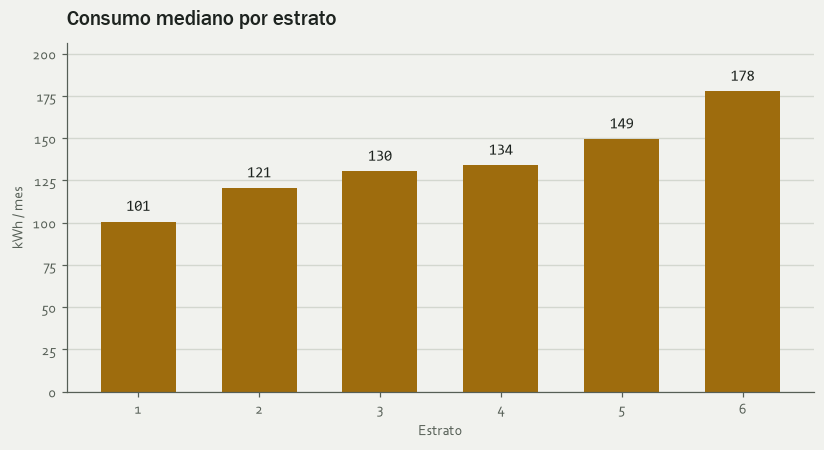

El estrato 6 gasta 178 kWh al mes contra 101 del estrato 1: 1,76 veces más.
En promedio, no en mediana, el 6 llega a 209 kWh.


In [11]:
serie = res.groupby("ESTRATO").lectura.median()
promedio = res.groupby("ESTRATO").lectura.mean()

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(serie.index, serie.values, width=0.62, color=COBRE[2], zorder=2)
for e, v in serie.items():
    ax.text(e, v + 4, "%.0f" % v, ha="center", va="bottom", fontsize=10, **DAT)
ax.set_xticks(serie.index)
ax.set_ylim(0, serie.max() * 1.16)
marco(ax, "Consumo mediano por estrato", x="Estrato", y="kWh / mes")
guardar(fig, "1_consumo_por_estrato.png")
plt.show()

print("El estrato 6 gasta %s kWh al mes contra %s del estrato 1: %s veces más."
      % (n(serie.loc[6]), n(serie.loc[1]), n(serie.loc[6] / serie.loc[1], 2)))
print("En promedio, no en mediana, el 6 llega a %s kWh." % n(promedio.loc[6]))

## ¿Cuánto gasta una manzana típica?

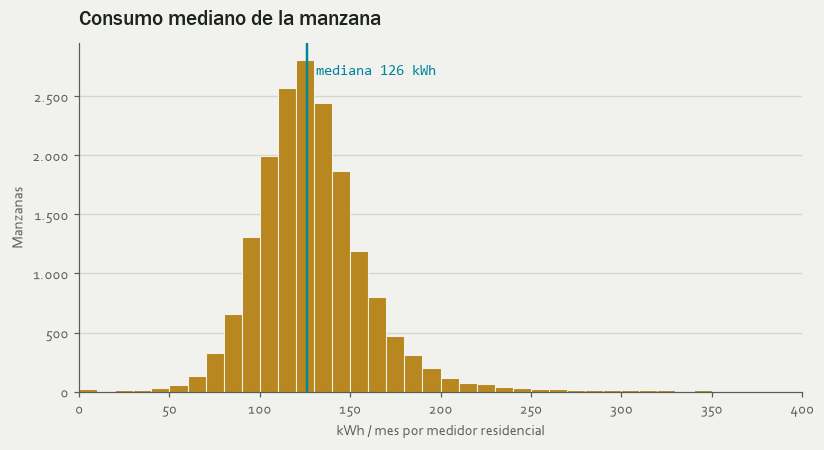

De las 17.888 manzanas con al menos tres medidores residenciales, la mitad está entre 109 y 144 kWh por medidor.
El gasto de una manzana entera suma en mediana 5.957 kWh al mes.


In [12]:
mz = manz[manz.med_residencial >= 3].copy()
mediana = mz.consumo_mediana.median()

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.hist(mz.consumo_mediana, bins=np.arange(0, 401, 10), color=COBRE[1],
        edgecolor=PAPEL, lw=0.7, zorder=2)
ax.axvline(mediana, color=PETROLEO, lw=1.6, zorder=3)
ax.text(mediana + 5, ax.get_ylim()[1] * 0.94, "mediana %s kWh" % n(mediana),
        color=PETROLEO, fontsize=9.5, va="top", **DAT)
ax.set_xlim(0, 400)
marco(ax, "Consumo mediano de la manzana", x="kWh / mes por medidor residencial",
      y="Manzanas")
guardar(fig, "2_consumo_por_manzana.png")
plt.show()

print("De las %s manzanas con al menos tres medidores residenciales, la mitad está"
      " entre %s y %s kWh por medidor."
      % (n(len(mz)), n(mz.consumo_mediana.quantile(0.25)),
         n(mz.consumo_mediana.quantile(0.75))))
print("El gasto de una manzana entera suma en mediana %s kWh al mes."
      % n((mz.consumo_mediana * mz.med_residencial).median()))

## ¿Dónde se gasta más por medidor?

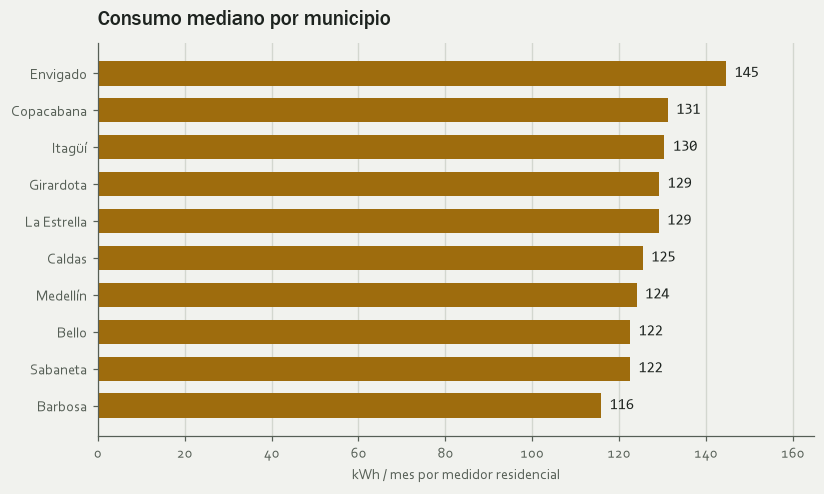

Envigado encabeza con 145 kWh y Barbosa cierra con 116.


In [13]:
por_mpio = res.groupby("N_Mpio").lectura.median().sort_values()

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.barh(por_mpio.index, por_mpio.values, height=0.66, color=COBRE[2], zorder=2)
for i, (m, v) in enumerate(por_mpio.items()):
    ax.text(v + 2, i, "%.0f" % v, va="center", fontsize=9.5, **DAT)
ax.set_xlim(0, por_mpio.max() * 1.14)
marco(ax, "Consumo mediano por municipio", x="kWh / mes por medidor residencial",
      eje_y_miles=False)
ax.grid(axis="x", color=LINEA, lw=0.9)
ax.grid(axis="y", visible=False)
guardar(fig, "3_consumo_por_municipio.png")
plt.show()

print("%s encabeza con %s kWh y %s cierra con %s."
      % (por_mpio.index[-1], n(por_mpio.iloc[-1]), por_mpio.index[0], n(por_mpio.iloc[0])))

## ¿Cuánta energía consume cada municipio en total?

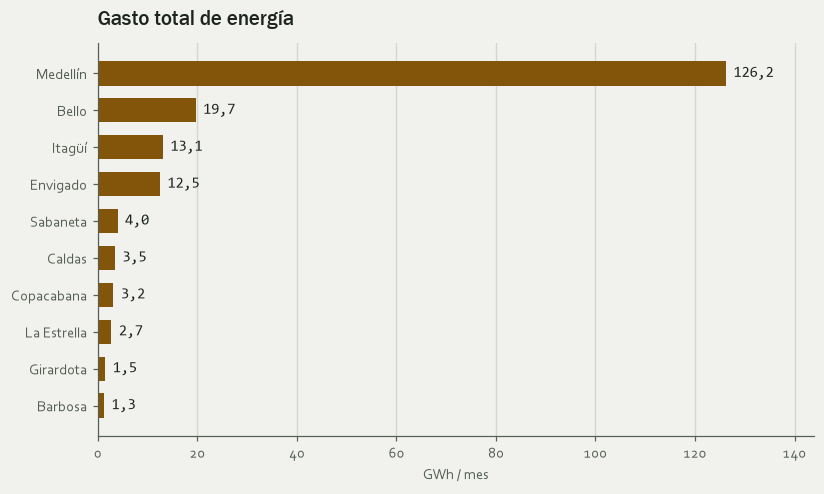

El valle suma 187,7 GWh al mes. Medellín pesa el 67,2 % de ese total.
La cifra es un piso: la fuente recorta el consumo en 1.000 kWh por medidor.


In [14]:
total = asignados.groupby("N_Mpio").lectura.sum().sort_values() / 1e6

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.barh(total.index, total.values, height=0.66, color=COBRE[3], zorder=2)
for i, (m, v) in enumerate(total.items()):
    ax.text(v + total.max() * 0.012, i, n(v, 1), va="center", fontsize=9.5, **DAT)
ax.set_xlim(0, total.max() * 1.14)
marco(ax, "Gasto total de energía", x="GWh / mes", eje_y_miles=False)
ax.grid(axis="x", color=LINEA, lw=0.9)
ax.grid(axis="y", visible=False)
guardar(fig, "4_gasto_total_por_municipio.png")
plt.show()

print("El valle suma %s GWh al mes. Medellín pesa el %s %% de ese total."
      % (n(total.sum(), 1), n(100 * total.loc["Medellín"] / total.sum(), 1)))
print("La cifra es un piso: la fuente recorta el consumo en 1.000 kWh por medidor.")

## ¿Qué tipo de instalación gasta más?

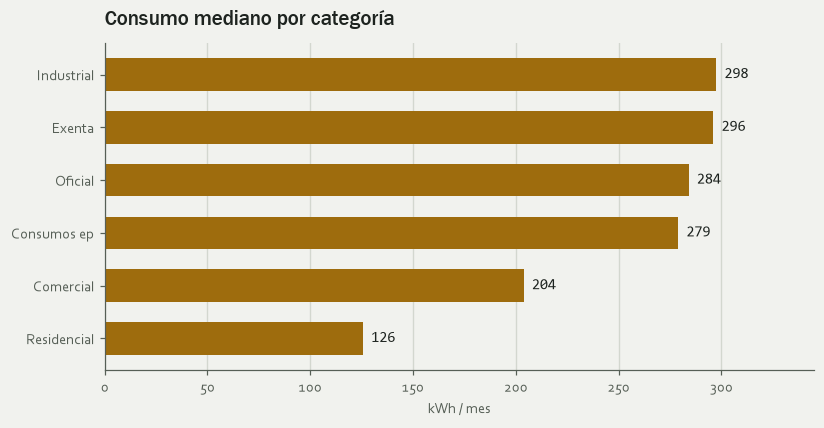

              mediana  medidores  con_lectura  sin_lectura_pct
Categoria                                                     
RESIDENCIAL  125.6670    1193739      1136911              4.8
COMERCIAL    203.8180      94040        71280             24.2
CONSUMOS EP  279.0000       2419         2181              9.8
OFICIAL      284.0835       2048          788             61.5
EXENTA       296.0910       1444          843             41.6
INDUSTRIAL   297.5000       9788         4589             53.1
En industrial y oficial más de la mitad de los medidores llega sin lectura, así que su mediana se calcula sobre los pocos que sí la traen.


In [15]:
cat = asignados.groupby("Categoria").agg(
    mediana=("lectura", "median"), medidores=("lectura", "size"),
    con_lectura=("lectura", "count"))
cat = cat[cat.con_lectura >= 500].sort_values("mediana")

fig, ax = plt.subplots(figsize=(7.6, 4))
ax.barh(cat.index.str.capitalize(), cat.mediana, height=0.62, color=COBRE[2], zorder=2)
for i, v in enumerate(cat.mediana):
    ax.text(v + 4, i, "%.0f" % v, va="center", fontsize=9.5, **DAT)
ax.set_xlim(0, cat.mediana.max() * 1.16)
marco(ax, "Consumo mediano por categoría", x="kWh / mes", eje_y_miles=False)
ax.grid(axis="x", color=LINEA, lw=0.9)
ax.grid(axis="y", visible=False)
guardar(fig, "5_consumo_por_categoria.png")
plt.show()

print(cat.assign(sin_lectura_pct=(100 * (1 - cat.con_lectura / cat.medidores)).round(1))
        .to_string())
print("En industrial y oficial más de la mitad de los medidores llega sin lectura,"
      " así que su mediana se calcula sobre los pocos que sí la traen.")

## ¿Cuántos medidores tiene una manzana?

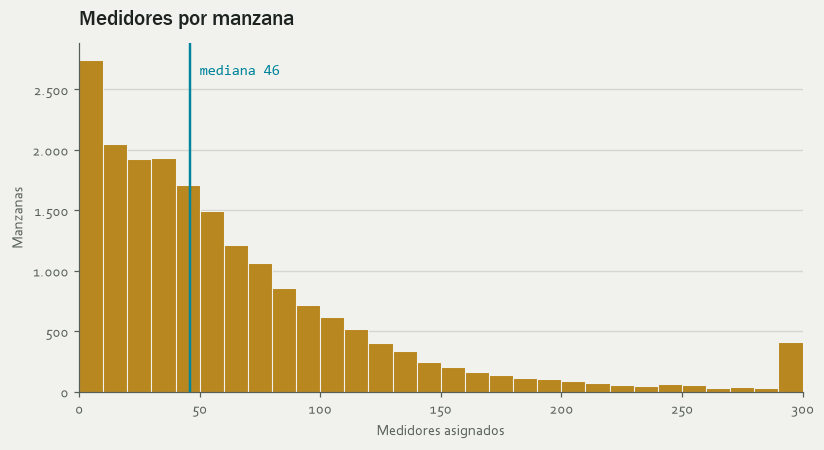

19.446 de 22.000 manzanas tienen al menos un medidor. La mediana es 46 medidores y el máximo 2.096.
Frente al censo, la razón mediana es de 0,91 medidores por vivienda censada.


In [16]:
con = manz[manz.medidores > 0]
mediana = con.medidores.median()

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.hist(con.medidores.clip(upper=300), bins=np.arange(0, 305, 10),
        color=COBRE[1], edgecolor=PAPEL, lw=0.7, zorder=2)
ax.axvline(mediana, color=PETROLEO, lw=1.6, zorder=3)
ax.text(mediana + 4, ax.get_ylim()[1] * 0.94, "mediana %s" % n(mediana),
        color=PETROLEO, fontsize=9.5, va="top", **DAT)
ax.set_xlim(0, 300)
marco(ax, "Medidores por manzana", x="Medidores asignados", y="Manzanas")
guardar(fig, "6_medidores_por_manzana.png")
plt.show()

print("%s de %s manzanas tienen al menos un medidor. La mediana es %s medidores"
      " y el máximo %s." % (n(len(con)), n(len(manz)), n(mediana), n(con.medidores.max())))
print("Frente al censo, la razón mediana es de %s medidores por vivienda censada."
      % n(manz[manz.TVIVIENDA > 0].med_x_vivienda.median(), 2))

## Cifras de referencia

In [17]:
resumen = pd.DataFrame([
    ("Medidores en la geodatabase", n(len(med))),
    ("Asignados a una manzana", "%s (%s %%)" % (n(len(asignados)),
                                                n(100 * len(asignados) / len(med), 1))),
    ("Direcciones distintas", n(med[["X", "Y"]].drop_duplicates().shape[0])),
    ("Manzanas del Valle de Aburrá", n(len(manz))),
    ("Manzanas con medidores", n(int((manz.medidores > 0).sum()))),
    ("Consumo mediano residencial", n(res.lectura.median()) + " kWh/mes"),
    ("Gasto total del valle", n(asignados.lectura.sum() / 1e6, 1) + " GWh/mes"),
    ("Medidores sin lectura", "%s (%s %%)" % (n(int(med.Csmo_Prom.eq(0).sum())),
                                              n(100 * med.Csmo_Prom.eq(0).mean(), 1))),
    ("Asignación ambigua entre dos manzanas", n(int(med.ambiguo.sum()))),
], columns=["", "valor"])
resumen.style.hide(axis="index")

,valor
Medidores en la geodatabase,1.362.005
Asignados a una manzana,"1.303.743 (95,7 %)"
Direcciones distintas,589.799
Manzanas del Valle de Aburrá,22.000
Manzanas con medidores,19.446
Consumo mediano residencial,126 kWh/mes
Gasto total del valle,"187,7 GWh/mes"
Medidores sin lectura,"92.835 (6,8 %)"
Asignación ambigua entre dos manzanas,51.155
